In [ ]:
# Prathmesh Durge, 23070521109

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LeakyReLU, Reshape, Flatten
from tensorflow.keras.optimizers import Adam


In [2]:

# Load MNIST
(x_train, _), (_, _) = mnist.load_data()
x_train = (x_train.astype("float32") - 127.5) / 127.5
x_train = x_train.reshape(-1, 784)

# Generator
generator = Sequential([
    Dense(128, input_dim=100),
    LeakyReLU(0.2),
    Dense(256),
    LeakyReLU(0.2),
    Dense(784, activation="tanh")
])

# Discriminator
discriminator = Sequential([
    Dense(256, input_dim=784),
    LeakyReLU(0.2),
    Dense(128),
    LeakyReLU(0.2),
    Dense(1, activation="sigmoid")
])

discriminator.compile(
    optimizer=Adam(0.0002, 0.5),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

c:\Users\Prathmesh\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:

# GAN
discriminator.trainable = False

gan = Sequential([
    generator,
    discriminator
])

gan.compile(
    optimizer=Adam(0.0002, 0.5),
    loss="binary_crossentropy"
)


In [6]:
# Train GAN
epochs = 100
batch_size = 64

train_acc = []
val_acc = []

x_val = x_train[-10000:]
x_train_main = x_train[:-10000]

for epoch in range(epochs):

    # -------------------------
    # Train Discriminator
    # -------------------------
    idx = np.random.randint(0, x_train_main.shape[0], batch_size)
    real = x_train_main[idx]

    noise = np.random.normal(0, 1, (batch_size, 100))
    fake = generator.predict(noise, verbose=0)

    discriminator.trainable = True

    real_result = discriminator.train_on_batch(
        real, np.ones((batch_size, 1))
    )

    fake_result = discriminator.train_on_batch(
        fake, np.zeros((batch_size, 1))
    )

    # Discriminator loss and accuracy
    d_loss = (real_result[0] + fake_result[0]) / 2
    train_accuracy = (real_result[1] + fake_result[1]) / 2

    # -------------------------
    # Validation
    # -------------------------
    idx = np.random.randint(0, x_val.shape[0], batch_size)
    val_real = x_val[idx]

    noise = np.random.normal(0, 1, (batch_size, 100))
    val_fake = generator.predict(noise, verbose=0)

    real_val = discriminator.evaluate(
        val_real,
        np.ones((batch_size, 1)),
        verbose=0
    )

    fake_val = discriminator.evaluate(
        val_fake,
        np.zeros((batch_size, 1)),
        verbose=0
    )

    validation_accuracy = (real_val[1] + fake_val[1]) / 2

    # -------------------------
    # Train Generator
    # -------------------------
    discriminator.trainable = False

    noise = np.random.normal(0, 1, (batch_size, 100))

    g_loss = gan.train_on_batch(
        noise,
        np.ones((batch_size, 1))
    )

    # -------------------------
    # Store results
    # -------------------------
    train_acc.append(train_accuracy)
    val_acc.append(validation_accuracy)

    # -------------------------
    # Display progress
    # -------------------------
    print(
        f"Epoch {epoch + 1}/{epochs} | "
        f"D Loss: {d_loss:.4f} | "
        f"D Acc: {train_accuracy:.4f} | "
        f"Val Acc: {validation_accuracy:.4f} | "
        f"G Loss: {g_loss:.4f}"
    )

Epoch 1/100 | D Loss: 0.4407 | D Acc: 0.8307 | Val Acc: 0.8203 | G Loss: 1.3095
Epoch 2/100 | D Loss: 0.4396 | D Acc: 0.8372 | Val Acc: 0.8516 | G Loss: 1.3095
Epoch 3/100 | D Loss: 0.5272 | D Acc: 0.7305 | Val Acc: 0.8438 | G Loss: 1.3093
Epoch 4/100 | D Loss: 0.4925 | D Acc: 0.7904 | Val Acc: 0.7969 | G Loss: 1.3092
Epoch 5/100 | D Loss: 0.4073 | D Acc: 0.8698 | Val Acc: 0.7578 | G Loss: 1.3092
Epoch 6/100 | D Loss: 0.4369 | D Acc: 0.7852 | Val Acc: 0.7656 | G Loss: 1.3093
Epoch 7/100 | D Loss: 0.4780 | D Acc: 0.7552 | Val Acc: 0.8281 | G Loss: 1.3091
Epoch 8/100 | D Loss: 0.5207 | D Acc: 0.7266 | Val Acc: 0.8828 | G Loss: 1.3090
Epoch 9/100 | D Loss: 0.4256 | D Acc: 0.8477 | Val Acc: 0.7969 | G Loss: 1.3090
Epoch 10/100 | D Loss: 0.4631 | D Acc: 0.8112 | Val Acc: 0.8281 | G Loss: 1.3090
Epoch 11/100 | D Loss: 0.4291 | D Acc: 0.8294 | Val Acc: 0.8125 | G Loss: 1.3089
Epoch 12/100 | D Loss: 0.4348 | D Acc: 0.8451 | Val Acc: 0.8594 | G Loss: 1.3088
Epoch 13/100 | D Loss: 0.4762 | D Acc

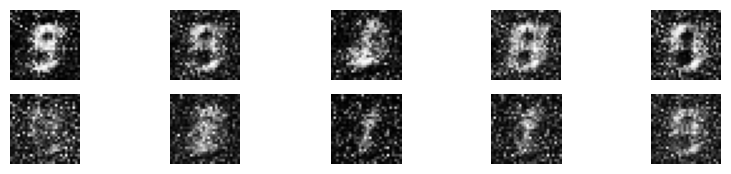

In [7]:

# Generate images
noise = np.random.normal(0, 1, (10, 100))
generated = generator.predict(noise, verbose=0)

# Visualize
plt.figure(figsize=(10, 2))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(generated[i].reshape(28, 28), cmap="gray")
    plt.axis("off")

plt.show()